# Import packages and datasets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from simulator import simulate
import pandas as pd

In [3]:
infected_df = pd.read_csv("infected_timeseries.csv")
rewiring_df = pd.read_csv("rewiring_timeseries.csv")
degree_df = pd.read_csv("final_degree_histograms.csv")

infected_values = []
for i in range(0, 40):
    df = infected_df[infected_df["replicate_id"] == i]
    result = df["infected_fraction"].values
    infected_values.append(np.array(result))

rewiring_values = []
for i in range(0, 40):
    df = rewiring_df[rewiring_df["replicate_id"] == i]
    result = df["rewire_count"].values
    rewiring_values.append(np.array(result))

degree_values = []
for i in range(0, 40):
    df = degree_df[degree_df["replicate_id"] == i]
    result = df["count"].values
    degree_values.append(np.array(result))
    
infected_values = np.array(infected_values)
rewiring_values = np.array(rewiring_values)
degree_values = np.array(degree_values)




obs_infected = np.mean(infected_values, axis = 0)
obs_rewiring = np.mean(rewiring_values, axis = 0)
obs_degree = np.mean(degree_values, axis = 0)

Check variance across 40 realizations

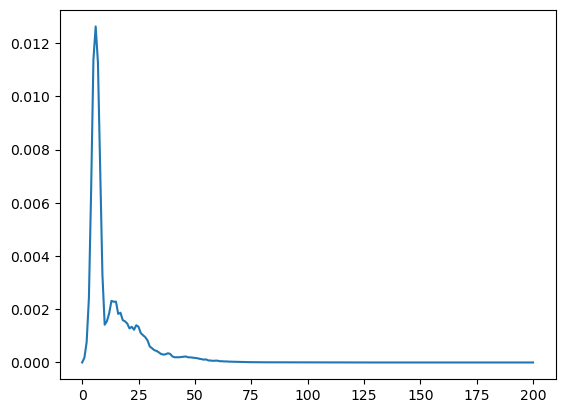

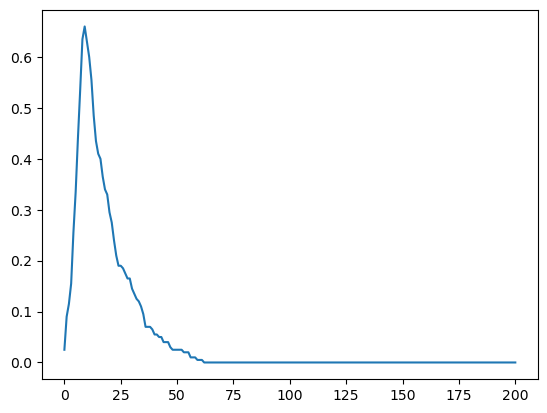

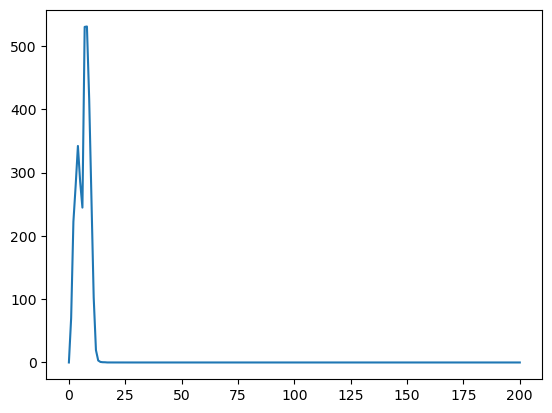

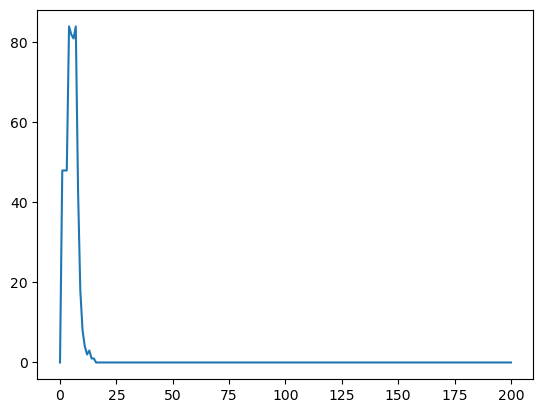

In [4]:
# var
plt.plot(range(201), np.var(np.array(infected_values).T, axis=1))

# compared with real y
plt.figure()
plt.plot(range(201),infected_values[35] )

plt.figure()
plt.plot(range(201), np.var(np.array(rewiring_values).T, axis=1))

plt.figure()
plt.plot(range(201),rewiring_values[35] )

Check mean across 40 realizations

<Figure size 640x480 with 0 Axes>

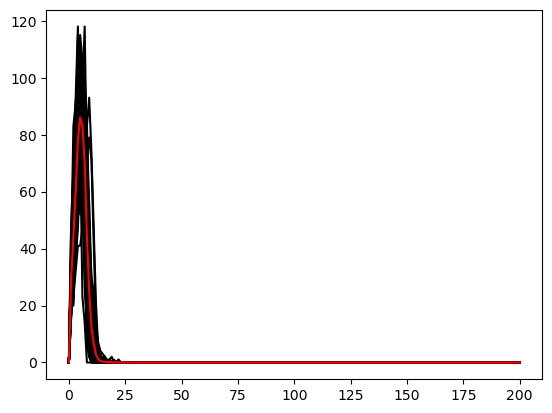

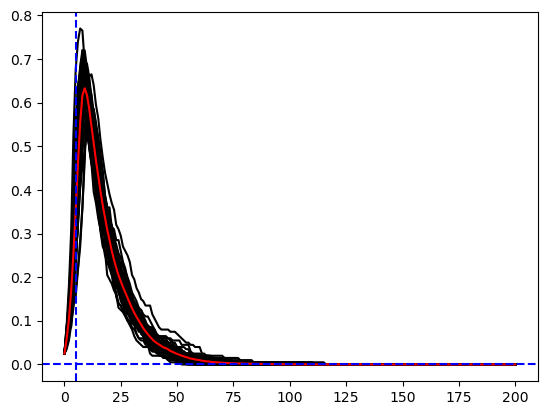

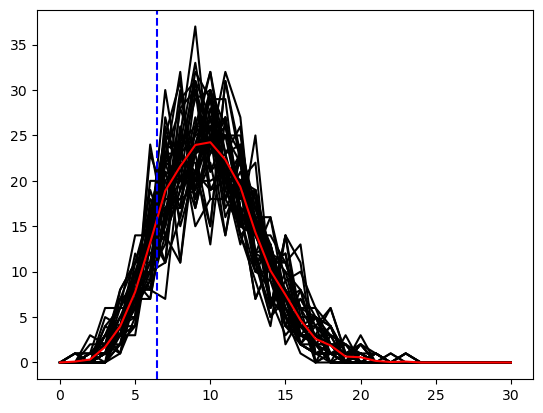

<Figure size 640x480 with 0 Axes>

In [5]:
# check mean of obs

for i in range(0, 40):
    plt.plot(range(201),rewiring_values[i], color= 'black')
plt.plot(range(201), np.mean(np.array(rewiring_values).T, axis = 1), color='red')

plt.figure()
for i in range(0, 40):
    plt.plot(range(201),infected_values[i], color = 'black')
plt.plot(range(201), np.mean(np.array(infected_values).T, axis = 1), color= 'red')
plt.axvline(x = 5,   linestyle = '--', color = 'blue')
plt.axhline(y = 0,   linestyle = '--', color = 'blue')

plt.figure()
for i in range(0, 40):
    plt.plot(range(31), degree_values[i], color = 'black')
plt.plot(range(31), np.mean(np.array(degree_values).T, axis = 1), color = 'red')
plt.axvline(x = np.mean(np.mean(np.array(degree_values).T, axis = 1)),   linestyle = '--', color = 'blue')

plt.figure()

# sim_data

In [6]:
beta_list = []
gamma_list = []
rho_list = []

sim_infected = []
sim_rewiring = []
sim_degree = []

N_sim = 20_000
rng = np.random.default_rng(42)

for _ in range(N_sim):
    # generate prior
    beta_prior = rng.uniform(0.05, 0.5)
    gamma_prior = rng.uniform(0.02, 0.2)
    rho_prior = rng.uniform(0, 0.8)
    
    beta_list.append(beta_prior)
    gamma_list.append(gamma_prior)
    rho_list.append(rho_prior)
    
    # sim_data
    infected, rewires, degrees = simulate(beta = beta_prior, gamma = gamma_prior, rho = rho_prior, rng = rng)
    
    sim_infected.append(infected)
    sim_rewiring.append(rewires)
    sim_degree.append(degrees)


beta_list = np.array(beta_list)
gamma_list = np.array(gamma_list)
rho_list = np.array(rho_list)

sim_infected = np.array(sim_infected)
sim_rewiring = np.array(sim_rewiring)
sim_degree = np.array(sim_degree)

# Summary statistics

### 1. choose a set of summary statistics (using 5% acceptance, norm distance function)

In [7]:
def check_all_zero_after_first_zero(infected_data):
    all_valid = True
    for idx, path in enumerate(infected_data):
        first_zero_idx = np.argmax(path < 1e-6)
        
        if first_zero_idx == 0 and path[0] > 1e-6:
            continue

        after_zero = path[first_zero_idx:]
        still_infected = np.sum(after_zero > 1e-6)
        
        if still_infected > 0:
            print(f"no")
            all_valid = False
    
    return all_valid

check_all_zero_after_first_zero(np.array(infected_values))

True

Standardization

In [8]:
peak_infected2 = np.max(sim_infected, axis = 1)
time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
total_Infected2 = np.sum(sim_infected, axis=1)                            
initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
duration2 = np.sum(sim_infected > 1e-6, axis = 1)
time_from_peak_to_end2 = duration2 - time_to_peak_infected2
       
total_rewire2 = np.sum(sim_rewiring, axis = 1)
peak_rewire2 = np.max(sim_rewiring, axis = 1)
time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
correlation2 = np.zeros_like(denom)
valid = denom > 0
correlation2[valid] = cov[valid] / denom[valid]

mean_final_degree2 = np.mean(sim_degree, axis =1)
var_final_degree2 = np.var(sim_degree, axis = 1)

ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)






peak_infected_std = np.std(peak_infected2)
time_to_peak_infected_std = np.std(time_to_peak_infected2)
total_Infected_std = np.std(total_Infected2)                            
initial_growth_std = np.std(initial_growth2)
initial_slope_std = np.std(initial_slope2)
duration_std = np.std(duration2)
       
total_rewire_std = np.std(total_rewire2)
peak_rewire_std = np.std(peak_rewire2)
time_to_peak_rewire_std = np.std(time_to_peak_rewire2)
correlation_std = np.std(correlation2)

mean_final_degree_std = np.std(mean_final_degree2)
var_final_degree_std = np.std(var_final_degree2)

ratio_std = np.std(ratio2)
width_at_half_peak_std = np.std(width_at_half_peak2)
time_from_peak_to_end_std = np.std(time_from_peak_to_end2)




peak_infected_mean = np.mean(peak_infected2)
time_to_peak_infected_mean = np.mean(time_to_peak_infected2)
total_Infected_mean = np.mean(total_Infected2)                            
initial_growth_mean = np.mean(initial_growth2)
initial_slope_mean = np.mean(initial_slope2)
duration_mean = np.mean(duration2)
       
total_rewire_mean = np.mean(total_rewire2)
peak_rewire_mean = np.mean(peak_rewire2)
time_to_peak_rewire_mean = np.mean(time_to_peak_rewire2)
correlation_mean = np.mean(correlation2)

mean_final_degree_mean = np.mean(mean_final_degree2)
var_final_degree_mean = np.mean(var_final_degree2)

ratio_mean = np.mean(ratio2)
width_at_half_peak_mean = np.mean(width_at_half_peak2)
time_from_peak_to_end_mean = np.mean(time_from_peak_to_end2)

Define functions

In [9]:
# return accepted samples and their idx
def accept_indices(distance, acceptance_rate):     
    eps = np.quantile(distance, acceptance_rate)
    indices = np.where(distance <= eps)[0]
    
    beta_accepted = beta_list[indices]
    gamma_accepted = gamma_list[indices]
    rho_accepted = rho_list[indices]
    return indices, beta_accepted, gamma_accepted, rho_accepted


# return three measures of 100 params sampled from accepted params
def test_on_summary(accepted_indices, s):
    
    posterior_test_indices = rng.choice(accepted_indices, size = s, replace = False)

    beta_test_posterior = beta_list[posterior_test_indices]
    gamma_test_posterior = gamma_list[posterior_test_indices]
    rho_test_posterior = rho_list[posterior_test_indices]

    posterior_test_infected = []
    posterior_test_rewiring = []
    posterior_test_degree = []

    for i in range(s):
        beta_posterior = beta_test_posterior[i]
        gamma_posterior = gamma_test_posterior[i]
        rho_posterior = rho_test_posterior[i]
        
        infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
        
        posterior_test_infected.append(infected)
        posterior_test_rewiring.append(rewires)
        posterior_test_degree.append(degrees)

    posterior_test_infected = np.array(posterior_test_infected)
    posterior_test_rewiring = np.array(posterior_test_rewiring)
    posterior_test_degree = np.array(posterior_test_degree)

    return posterior_test_infected, posterior_test_rewiring, posterior_test_degree



def compute_measurements_mse(posterior_test_infected,  posterior_test_rewiring,posterior_test_degree, obs_infected, obs_rewiring, obs_degree  ):

    infect_mse = np.mean((posterior_test_infected - obs_infected)**2)
    rewire_mse = np.mean((posterior_test_rewiring - obs_rewiring)**2)
    degree_mse = np.mean((posterior_test_degree - obs_degree)**2)
    
    print(f"mse (infection, rewiring, degree): {[infect_mse, rewire_mse, degree_mse]}")
    


def compute_params_mse_std(accepted_beta, accepted_gamma, accepted_rho):
    theta_true = np.array([0.25, 0.1, 0.3])
    beta_std = np.std(accepted_beta)
    gamma_std = np.std(accepted_gamma)
    rho_std = np.std(accepted_rho)
    
    beta_mse = np.mean((accepted_beta - theta_true[0])**2)
    gamma_mse = np.mean((accepted_gamma - theta_true[1])**2)
    rho_mse = np.mean((accepted_rho - theta_true[2])**2)
    
    print(f"std (beta, gamma, rho):{np.array([beta_std, gamma_std, rho_std])}")
    print(f"mse (beta, gamma, rho):{np.array([beta_mse, gamma_mse, rho_mse])}")



colors = ['red', 'green', 'blue', 'orange', 'purple']
def plot_beta_across_summary(posterior):

    for i in range(len(posterior)):
        c = colors[i % len(colors)]

        plt.hist(
            posterior[i],
            density=True,
            bins=50,
            histtype='step',
            color=c,
            label=f"set {i+1}"
        )

        plt.axvline(
            x=np.mean(posterior[i]),
            linestyle='--',
            color=c,
            label=f"set {i+1} mean"
        )

    # prior
    x_axis_beta = np.linspace(0.05, 0.5, 100)
    y_axis_beta = np.ones(100) * (1 / 0.45)
    plt.plot(x_axis_beta, y_axis_beta, color='black')

    plt.axvline(
        x=(0.05 + 0.5) / 2,   
        linestyle='--',
        color='black',
        label='prior mean'
    )

    plt.title("Posterior of beta")
    plt.legend()



def plot_gamma_across_summary(posterior):
    for i in range(len(posterior)):
        c = colors[i % len(colors)]

        plt.hist(
            posterior[i],
            density=True,
            bins=50,
            alpha=0.6,
            label=f"set {i+1}",
            histtype='step',
            color=c
        )

        plt.axvline(
            x=np.mean(posterior[i]),
            linestyle='--',
            color=c,
            label=f'set {i+1} posterior mean'
        )

    x_axis_gamma = np.linspace(0.02, 0.2, 100)
    y_axis_gamma = np.ones(100) * (1 / 0.18)
    plt.plot(x_axis_gamma, y_axis_gamma, color='black')

    plt.axvline(
        x=(0.02 + 0.2)/2,
        linestyle='--',
        label='prior mean',
        color='black'
    )

    plt.legend()
    
    
def plot_rho_across_summary(posterior):
    for i in range(len(posterior)):
        c = colors[i % len(colors)]

        plt.hist(
            posterior[i],
            density=True,
            bins=50,
            alpha=0.6,
            label=f"set {i+1}",
            histtype='step',
            color=c
        )

        plt.axvline(
            x=np.mean(posterior[i]),
            linestyle='--',
            color=c,
            label=f'set {i+1} posterior mean'
        )

    x_axis_rho = np.linspace(0, 0.8, 100)
    y_axis_rho = np.ones(100) * (1 / 0.8)
    plt.plot(x_axis_rho, y_axis_rho, color='black')

    plt.axvline(
        x=0.8/2,
        linestyle='--',
        label='prior mean',
        color='black'
    )

    plt.legend()




def joint_posterior(beta_samples, gamma_samples, rho_samples):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 

    axes[0].scatter(beta_samples, gamma_samples, s=10, alpha=0.5)
    axes[0].set_xlabel("accepted beta posterior")
    axes[0].set_ylabel("accepted gamma posterior")

    axes[1].scatter(beta_samples, rho_samples, s=10, alpha=0.5)
    axes[1].set_xlabel("accepted beta posterior")
    axes[1].set_ylabel("accepted rho posterior")

    axes[2].scatter(gamma_samples, rho_samples, s=10, alpha=0.5)
    axes[2].set_xlabel("accepted gamma posterior")
    axes[2].set_ylabel("accepted rho posterior")

    plt.tight_layout()
    plt.show()
    
    
def plot_measurements(measure_set1, measure_set2, measure_set3,
                      measure2_set1, measure2_set2, measure2_set3,
                      measure3_set1, measure3_set2, measure3_set3,
                      obs, obs2, obs3):

    fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 
    
    for i in range(len(measure_set1)):
        axes[0].plot(range(201), measure_set1[i], color='green', alpha=0.2)
        axes[0].plot(range(201), measure_set2[i], color='blue', alpha=0.2)
        axes[0].plot(range(201), measure_set3[i], color='orange', alpha=0.2)
        
        axes[1].plot(range(201), measure2_set1[i], color='green', alpha=0.2)
        axes[1].plot(range(201), measure2_set2[i], color='blue', alpha=0.2)
        axes[1].plot(range(201), measure2_set3[i], color='orange', alpha=0.2)
        
        axes[2].plot(range(31), measure3_set1[i], color='green', alpha=0.2)
        axes[2].plot(range(31), measure3_set2[i], color='blue', alpha=0.2)
        axes[2].plot(range(31), measure3_set3[i], color='orange', alpha=0.2)

    axes[0].plot(range(201), obs, color='red', label='Observed')
    axes[1].plot(range(201), obs2, color='red')
    axes[2].plot(range(31), obs3, color='red')

    axes[0].plot([], [], color='green', label='Set 1')
    axes[0].plot([], [], color='blue', label='Set 2')
    axes[0].plot([], [], color='orange', label='Set 3')

    axes[0].legend()
    axes[0].set_title("Posterior predictive: infection")
    axes[1].set_title("Posterior predictive: rewiring")
    axes[2].set_title("Posterior predictive: degree")

    plt.tight_layout()
    

Define acceptance rate

In [10]:
acceptance_rate = 0.05
s = 100

Set 1

In [11]:
def set_2_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    
    return peak_infected_norm, total_Infected_norm, initial_slope_norm, total_rewire_norm, peak_rewire_norm, mean_final_degree_norm, ratio_norm, width_at_half_peak_norm, duration_norm



def set_2_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    
    return peak_infected_norm2, total_Infected_norm2, initial_slope_norm2, total_rewire_norm2, peak_rewire_norm2, mean_final_degree_norm2, ratio_norm2, width_at_half_peak_norm2, duration_norm2

In [12]:
summary_test2_train = set_2_summary_obs(obs_infected, obs_rewiring, obs_degree)       
summary_test2_sim = set_2_summary_sim(sim_infected, sim_rewiring, sim_degree)

summary_test2_sim = np.array(summary_test2_sim).T
summary_test2_train = np.array(summary_test2_train)

distance = np.linalg.norm(summary_test2_train - summary_test2_sim, axis = 1)      
                                                 
indices_test2_5, beta_test2_5, gamma_test2_5, rho_test2_5  = accept_indices(distance, acceptance_rate)

posterior_test2_infected, posterior_test2_rewiring, posterior_test2_degree = test_on_summary(indices_test2_5, s)

compute_measurements_mse(posterior_test2_infected, posterior_test2_rewiring, posterior_test2_degree, obs_infected, obs_rewiring, obs_degree)
compute_params_mse_std(beta_test2_5, gamma_test2_5, rho_test2_5)

mse (infection, rewiring, degree): [0.0027893707711442784, 66.74090547263681, 6.711088709677419]
std (beta, gamma, rho):[0.05657476 0.02259306 0.11137103]
mse (beta, gamma, rho):[0.0092591  0.00075431 0.01241147]


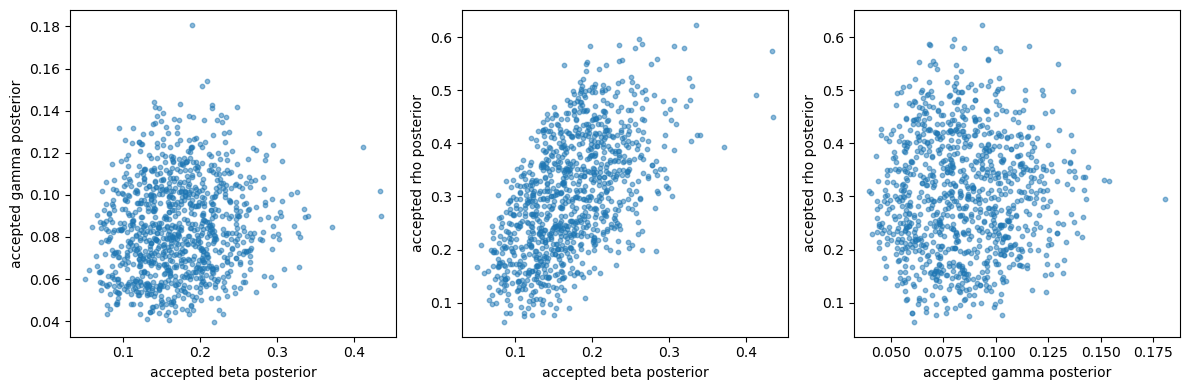

In [13]:
joint_posterior(beta_test2_5, gamma_test2_5, rho_test2_5)

Set 2:

In [14]:
def set_3_summary_obs(obs_infected, obs_rewiring, obs_degree):       # 7 stats
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    time_from_peak_to_end_norm = (time_from_peak_to_end - time_from_peak_to_end_mean) / time_from_peak_to_end_std
    
    return    ratio_norm, peak_rewire_norm, mean_final_degree_norm , total_Infected_norm, initial_slope_norm, width_at_half_peak_norm


def set_3_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    time_from_peak_to_end_norm2 = (time_from_peak_to_end2 - time_from_peak_to_end_mean) / time_from_peak_to_end_std
    
    return    ratio_norm2, peak_rewire_norm2, mean_final_degree_norm2, total_Infected_norm2, initial_slope_norm2, width_at_half_peak_norm2


In [15]:
summary_test3_train = set_3_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test3_sim = set_3_summary_sim(sim_infected, sim_rewiring, sim_degree)

summary_test3_sim = np.array(summary_test3_sim).T
summary_test3_train = np.array(summary_test3_train)

distance = np.linalg.norm(summary_test3_train - summary_test3_sim, axis = 1)      
                                                 
indices_test3_5, beta_test3_5, gamma_test3_5, rho_test3_5  = accept_indices(distance, acceptance_rate)

posterior_test3_infected, posterior_test3_rewiring, posterior_test3_degree = test_on_summary(indices_test3_5, s)

compute_measurements_mse(posterior_test3_infected, posterior_test3_rewiring, posterior_test3_degree, obs_infected, obs_rewiring, obs_degree)
compute_params_mse_std(beta_test3_5, gamma_test3_5, rho_test3_5)

mse (infection, rewiring, degree): [0.0024588937189054722, 58.670808457711445, 6.483249999999999]
std (beta, gamma, rho):[0.04526538 0.0284692  0.10712216]
mse (beta, gamma, rho):[0.00944431 0.00081308 0.01197202]


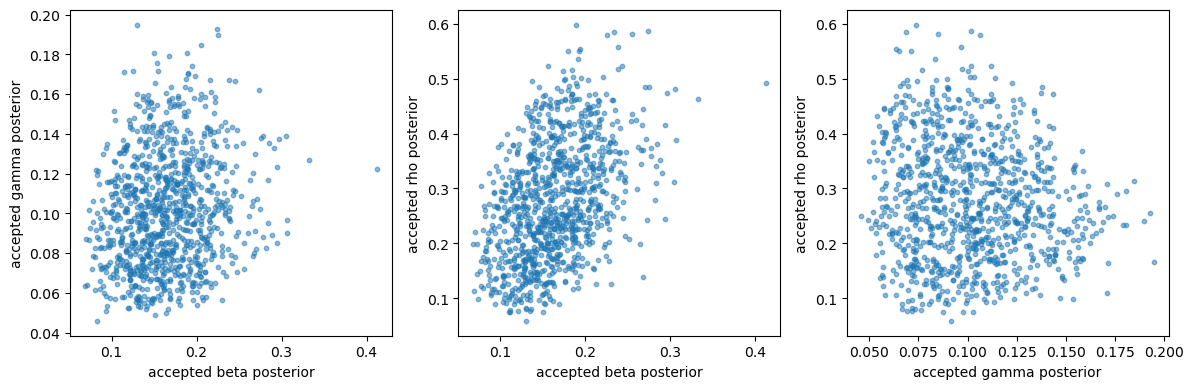

In [16]:
joint_posterior(beta_test3_5, gamma_test3_5, rho_test3_5)

Set 3:

In [17]:
def set_5_summary_obs(obs_infected, obs_rewiring, obs_degree):

    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    time_from_peak_to_end_norm = (time_from_peak_to_end - time_from_peak_to_end_mean) / time_from_peak_to_end_std

    return peak_infected_norm, time_to_peak_infected_norm , peak_rewire_norm, ratio_norm, width_at_half_peak_norm, mean_final_degree_norm



def set_5_summary_sim(sim_infected, sim_rewiring, sim_degree):

    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    time_from_peak_to_end_norm2 = (time_from_peak_to_end2 - time_from_peak_to_end_mean) / time_from_peak_to_end_std
    
    return peak_infected_norm2,time_to_peak_infected_norm2 , peak_rewire_norm2, ratio_norm2, width_at_half_peak_norm2, mean_final_degree_norm2

In [18]:
summary_test5_train = set_5_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test5_sim = set_5_summary_sim(sim_infected, sim_rewiring, sim_degree)

summary_test5_sim = np.array(summary_test5_sim).T
summary_test5_train = np.array(summary_test5_train)

distance = np.linalg.norm(summary_test5_train - summary_test5_sim, axis = 1)

indices_test5_5, beta_test52_5, gamma_test52_5, rho_test52_5  = accept_indices(distance, acceptance_rate )

posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree = test_on_summary(indices_test5_5, s)

compute_measurements_mse(posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree, obs_infected, obs_rewiring, obs_degree)
compute_params_mse_std(beta_test52_5, gamma_test52_5, rho_test52_5)

mse (infection, rewiring, degree): [0.0027621856965174122, 67.39568905472638, 6.353104838709678]
std (beta, gamma, rho):[0.04912608 0.0255863  0.09551476]
mse (beta, gamma, rho):[0.00728865 0.00066825 0.00980413]


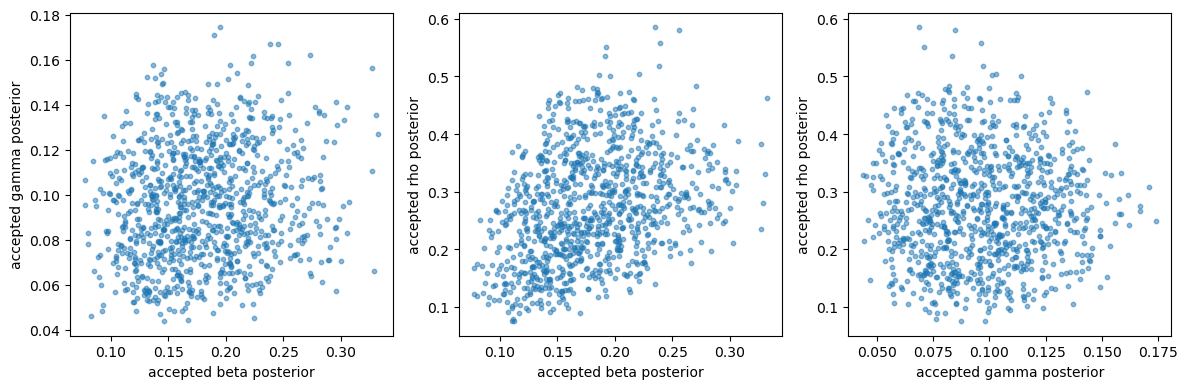

In [19]:
joint_posterior(beta_test52_5, gamma_test52_5, rho_test52_5)

### Comparision across 3 sets

compare posterior distribution

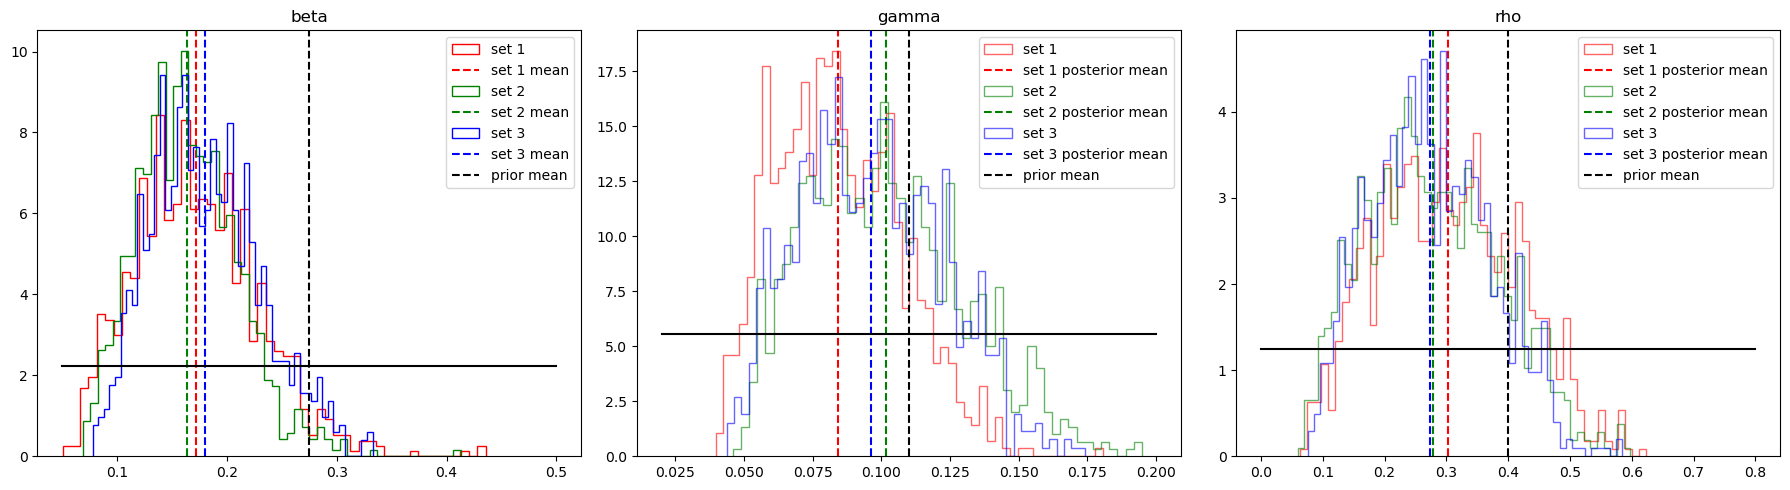

In [20]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_beta_across_summary([beta_test2_5, beta_test3_5, beta_test52_5])
plt.title("beta")

plt.subplot(1, 3, 2)
plot_gamma_across_summary([gamma_test2_5, gamma_test3_5, gamma_test52_5])
plt.title("gamma")

plt.subplot(1, 3, 3)
plot_rho_across_summary([rho_test2_5, rho_test3_5,rho_test52_5])
plt.title("rho")

plt.tight_layout()
plt.show()

Compare pair-wise joint posteriors

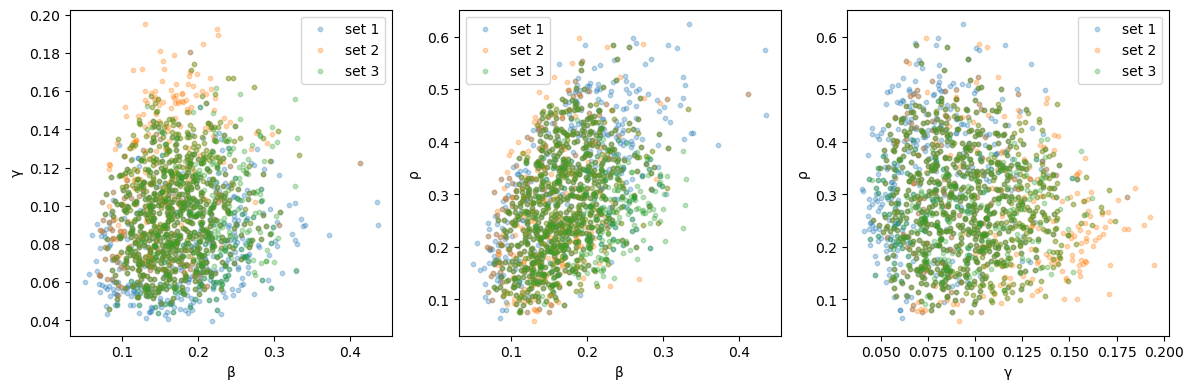

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 

axes[0].scatter(beta_test2_5, gamma_test2_5, s=10, alpha=0.3, label="set 1")
axes[0].scatter(beta_test3_5, gamma_test3_5, s=10, alpha=0.3, label="set 2")
axes[0].scatter(beta_test52_5, gamma_test52_5, s=10, alpha=0.3, label="set 3")
axes[0].set_xlabel("β")
axes[0].set_ylabel("γ")
axes[0].legend()


axes[1].scatter(beta_test2_5, rho_test2_5, s=10, alpha=0.3, label="set 1")
axes[1].scatter(beta_test3_5, rho_test3_5, s=10, alpha=0.3, label="set 2")
axes[1].scatter(beta_test52_5, rho_test52_5, s=10, alpha=0.3, label="set 3")
axes[1].set_xlabel("β")
axes[1].set_ylabel("ρ")
axes[1].legend()


axes[2].scatter(gamma_test2_5, rho_test2_5, s=10, alpha=0.3, label="set 1")
axes[2].scatter(gamma_test3_5, rho_test3_5, s=10, alpha=0.3, label="set 2")
axes[2].scatter(gamma_test52_5, rho_test52_5, s=10, alpha=0.3, label="set 3")
axes[2].set_xlabel("γ")
axes[2].set_ylabel("ρ")
axes[2].legend()


plt.tight_layout()
plt.show()

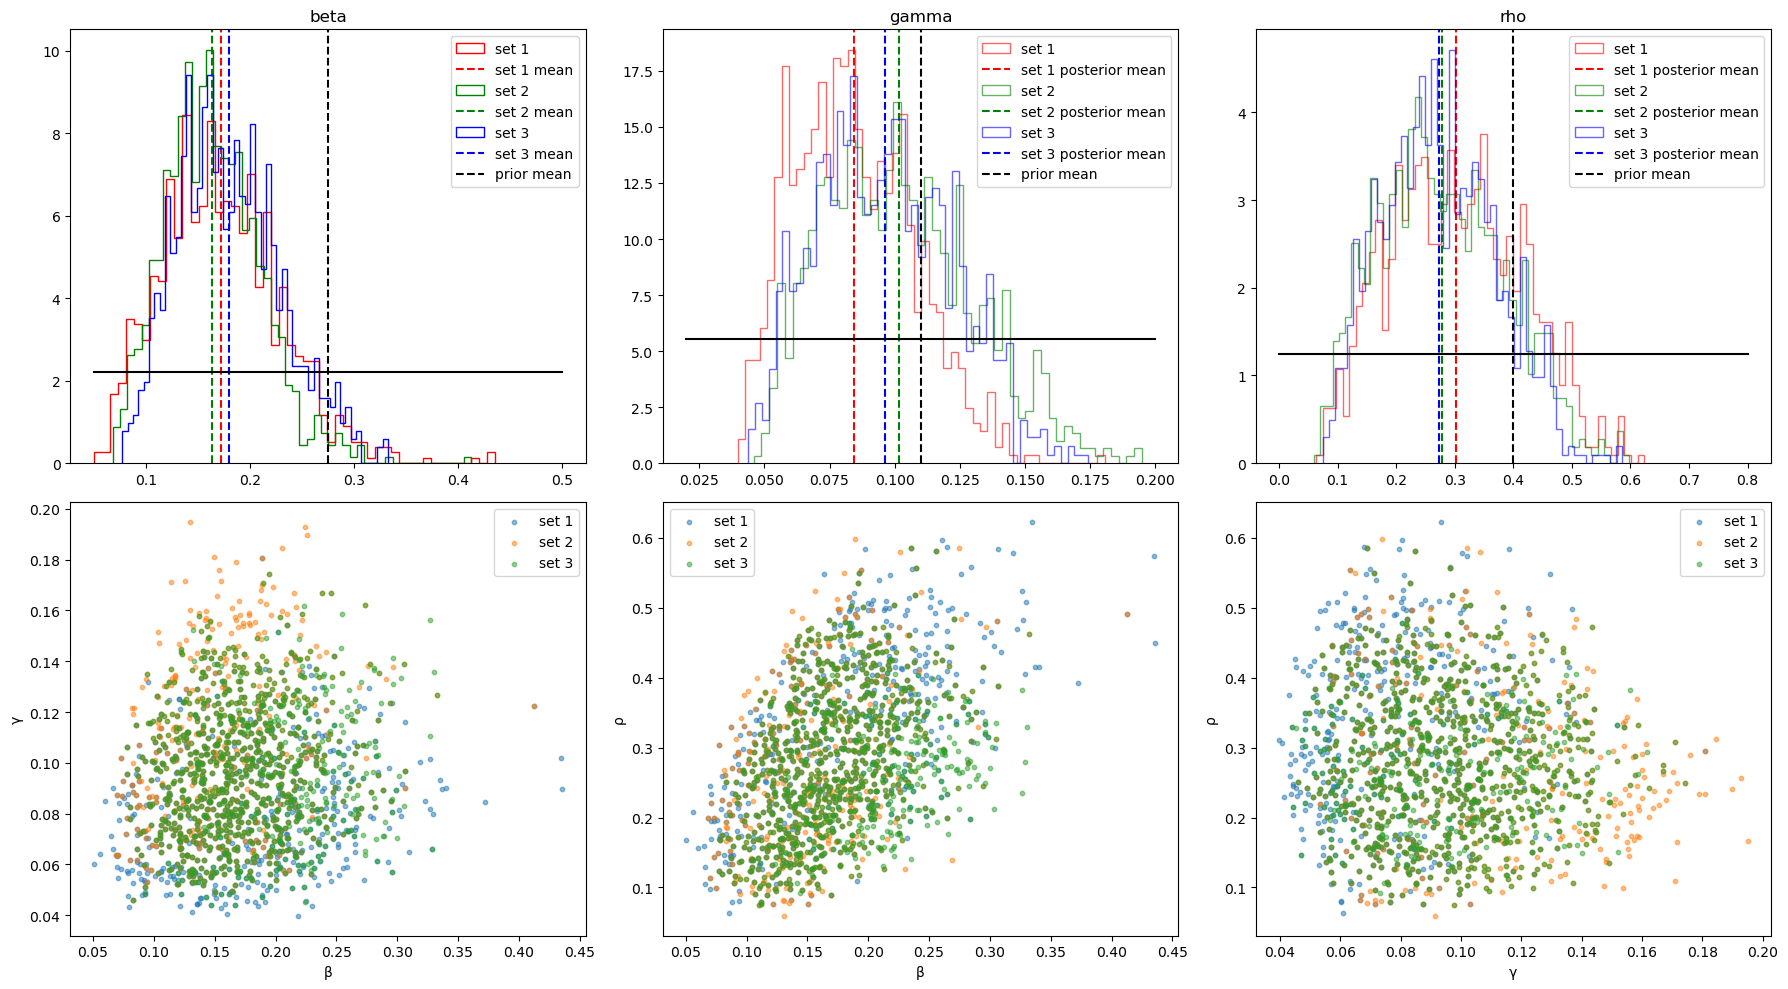

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


plt.sca(axes[0, 0])
plot_beta_across_summary([beta_test2_5, beta_test3_5, beta_test52_5])
plt.title("beta")

plt.sca(axes[0, 1])
plot_gamma_across_summary([gamma_test2_5, gamma_test3_5, gamma_test52_5])
plt.title("gamma")

plt.sca(axes[0, 2])
plot_rho_across_summary([rho_test2_5, rho_test3_5, rho_test52_5])
plt.title("rho")


# β vs γ
axes[1, 0].scatter(beta_test2_5, gamma_test2_5, s=10, alpha=0.5, label="set 1")
axes[1, 0].scatter(beta_test3_5, gamma_test3_5, s=10, alpha=0.5, label="set 2")
axes[1, 0].scatter(beta_test52_5, gamma_test52_5, s=10, alpha=0.5, label="set 3")
axes[1, 0].set_xlabel("β")
axes[1, 0].set_ylabel("γ")
axes[1, 0].legend()

# β vs ρ
axes[1, 1].scatter(beta_test2_5, rho_test2_5, s=10, alpha=0.5, label="set 1")
axes[1, 1].scatter(beta_test3_5, rho_test3_5, s=10, alpha=0.5, label="set 2")
axes[1, 1].scatter(beta_test52_5, rho_test52_5, s=10, alpha=0.5, label="set 3")
axes[1, 1].set_xlabel("β")
axes[1, 1].set_ylabel("ρ")
axes[1, 1].legend()

# γ vs ρ
axes[1, 2].scatter(gamma_test2_5, rho_test2_5, s=10, alpha=0.5, label="set 1")
axes[1, 2].scatter(gamma_test3_5, rho_test3_5, s=10, alpha=0.5, label="set 2")
axes[1, 2].scatter(gamma_test52_5, rho_test52_5, s=10, alpha=0.5, label="set 3")
axes[1, 2].set_xlabel("γ")
axes[1, 2].set_ylabel("ρ")
axes[1, 2].legend()


plt.tight_layout()
plt.show()

Compare posteior measurements

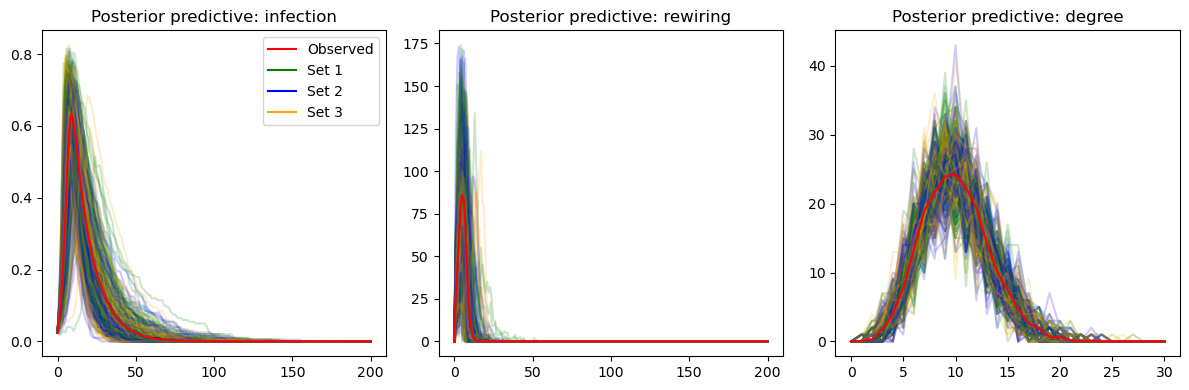

In [24]:
plot_measurements(posterior_test2_infected, posterior_test3_infected, posterior_test5_infected, 
                  posterior_test2_rewiring, posterior_test3_rewiring, posterior_test5_rewiring, 
                  posterior_test2_degree, posterior_test3_degree, posterior_test5_degree, 
                  obs_infected, obs_rewiring, obs_degree
                  )